# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = "Churn_Modelling.csv"

In [4]:
## TODO : make into a dataframe called df
df = pd.read_csv(file_1)

In [5]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df["Exited"] == 0]
df_1 = df[df["Exited"] == 1]

## Hypothesis 1: Age

In [ ]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

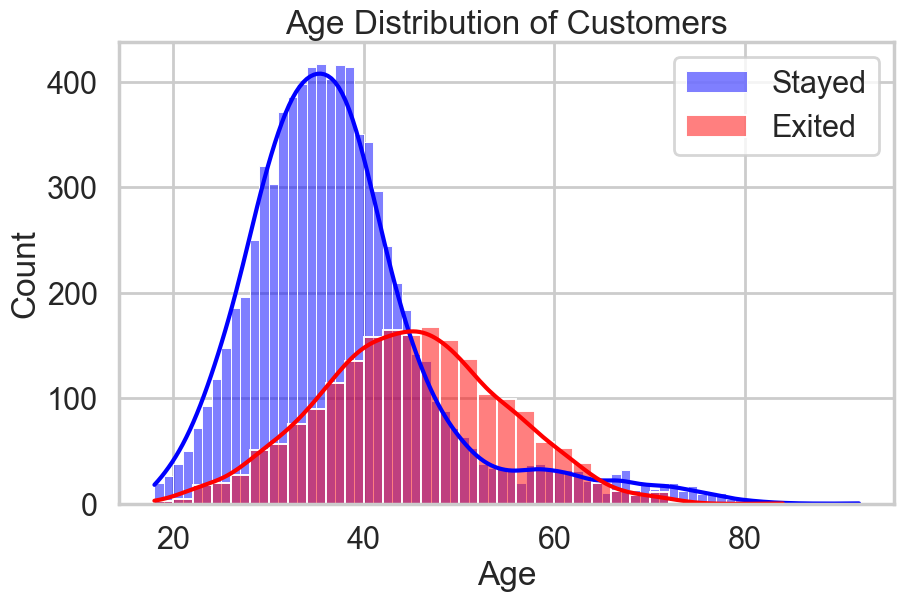

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(df_0["Age"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1["Age"], color="red", label="Exited", kde=True)

plt.legend()
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [ ]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.

In [8]:
mean_age = df_0["Age"].mean()
std_age = df_0["Age"].std()

print("Mean Age (Stayed Customers):", mean_age)
print("Standard Deviation of Age (Stayed Customers):", std_age)

Mean Age (Stayed Customers): 37.40838879819164
Standard Deviation of Age (Stayed Customers): 10.125362911047539


In [ ]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.

In [9]:
mean_age = df_1["Age"].mean()
std_age = df_1["Age"].std()

print("Mean Age (Stayed Customers):", mean_age)
print("Standard Deviation of Age (Stayed Customers):", std_age)

Mean Age (Stayed Customers): 44.8379970544919
Standard Deviation of Age (Stayed Customers): 9.76156155550719


In [ ]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.

In [12]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0["Age"], df_1["Age"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -29.76681499437077
P-value: 1.2399313093427736e-186


p-value < 0.05
--> il existe une différence significative d’âge entre les clients qui restent et ceux qui quittent.

On rejette donc l’hypothèse nulle (H₀) qui suppose qu'il n’y a aucune différence d’âge entre les deux groupes.

### Interprétation métier  

L’âge semble être un facteur important dans le churn des clients.

Selon les résultats du dataset utilisé dans ce challenge :

- les clients plus âgés ont tendance à quitter la banque plus souvent

- les clients plus jeunes restent plus longtemps

Cela signifie que la banque pourrait :

- analyser les besoins des clients plus âgés

- proposer des services ou offres spécifiques

- améliorer les stratégies de rétention

### Using Bootstrapping

In [13]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [ ]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.

In [14]:
# difference des moyennes observées
mean_diff = df_1["Age"].mean() - df_0["Age"].mean()

# moyenne globale
overall_mean = df["Age"].mean()

# shift des deux groupes vers la moyenne globale
age_stayed_shifted = df_0["Age"] - df_0["Age"].mean() + overall_mean
age_left_shifted = df_1["Age"] - df_1["Age"].mean() + overall_mean

In [ ]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

In [15]:
# nombre d'échantillons bootstrap
bs_size = 10000

bs_stayed = bs_choice(age_stayed_shifted, np.mean, bs_size)
bs_left = bs_choice(age_left_shifted, np.mean, bs_size)

# distribution bootstrap de la différence des moyennes
bs_diff = bs_left - bs_stayed

In [ ]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.

In [16]:
p_value = np.sum(bs_diff >= mean_diff) / len(bs_diff)

print("Observed difference in means:", mean_diff)
print("Bootstrap p-value:", p_value)

Observed difference in means: 7.429608256300263
Bootstrap p-value: 0.0


la différence d’âge est statistiquement significative.

--> Cela confirmera le résultat du t-test que j'ai déjà obtenu.

### Conclusion
On rejette donc l’hypothèse nulle (H₀) qui suppose qu'il n’y a aucune différence d’âge entre les deux groupes.

## Hypothesis 2: Credit Score

In [19]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

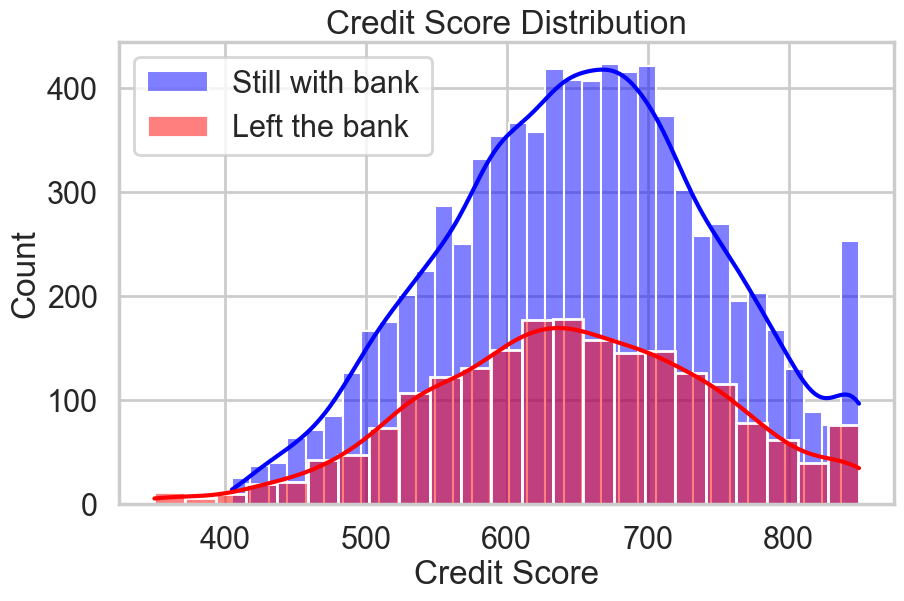

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df_0["CreditScore"], color="blue", label="Still with bank", kde=True)
sns.histplot(df_1["CreditScore"], color="red", label="Left the bank", kde=True)

plt.legend()
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

In [ ]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

In [20]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0["CreditScore"], df_1["CreditScore"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.7100778888729833
P-value: 0.006738213892192373


### Conclusion
p-value < 0.05

we reject the null hypothesis and conclude that there is a statistically significant difference in CreditScore between the two groups.

## Hypothesis 3: Balance

In [ ]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

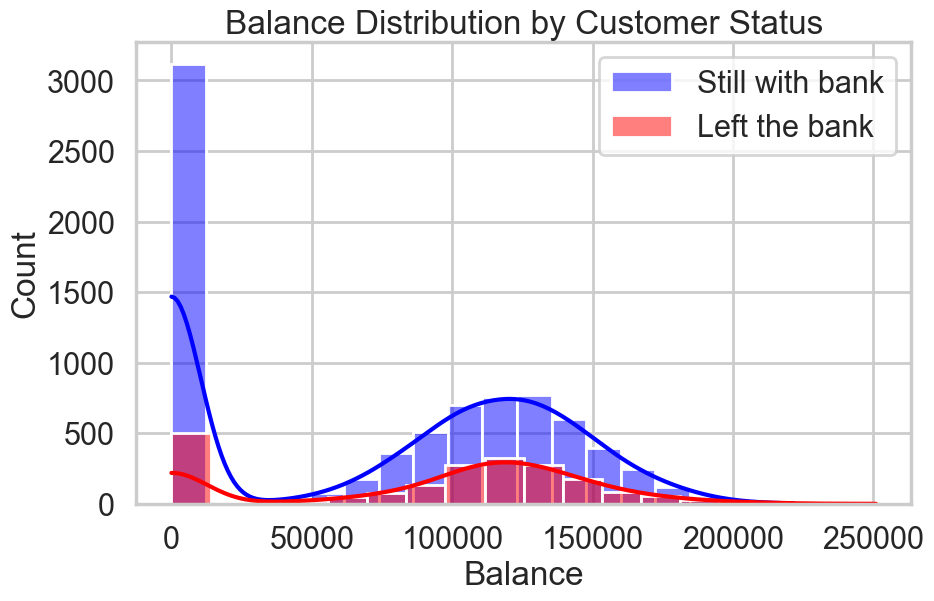

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df_0["Balance"], color="blue", label="Still with bank", kde=True)
sns.histplot(df_1["Balance"], color="red", label="Left the bank", kde=True)

plt.legend()
plt.title("Balance Distribution by Customer Status")
plt.xlabel("Balance")
plt.ylabel("Count")

plt.show()

In [22]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

In [23]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0["Balance"], df_1["Balance"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -11.936240300013841
P-value: 1.2755633191525477e-32


p-value < 0.05 --> différence significative de balance

In [ ]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

In [24]:
df_0_nonzero = df_0[df_0["Balance"] > 0]
df_1_nonzero = df_1[df_1["Balance"] > 0]

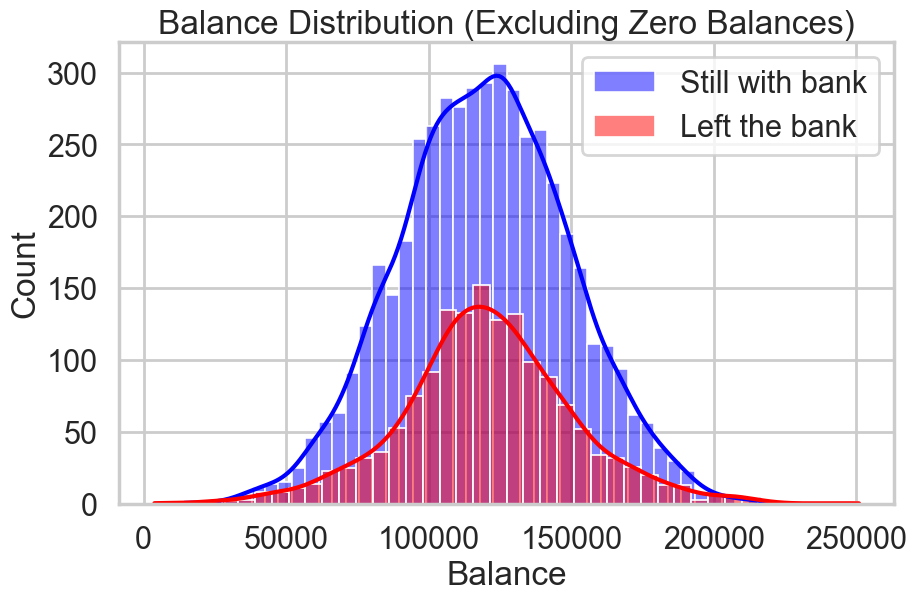

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(df_0_nonzero["Balance"], color="blue", label="Still with bank", kde=True)
sns.histplot(df_1_nonzero["Balance"], color="red", label="Left the bank", kde=True)

plt.legend()
plt.title("Balance Distribution (Excluding Zero Balances)")
plt.xlabel("Balance")
plt.ylabel("Count")

plt.show()

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

In [26]:
t_stat_nz, p_value_nz = ttest_ind(df_0_nonzero["Balance"], df_1_nonzero["Balance"])

print("T-statistic (no zero balances):", t_stat_nz)
print("P-value (no zero balances):", p_value_nz)

T-statistic (no zero balances): -1.374781881782122
P-value (no zero balances): 0.16924734893322796


p-value ≥ 0.05 -->  pas de différence significative entre les balances des deux groupes lorsque l’on exclut les comptes avec un balance égal à zéro.

## Conclusion

The first t-test including all balances produced a very small p-value (1.27e-32), 
so we reject the null hypothesis and conclude that there is a significant difference 
in balance between customers who stayed and those who left.

However, after excluding accounts with zero balance, the p-value becomes 0.169, 
which is greater than 0.05. Therefore, we fail to reject the null hypothesis.

This indicates that the difference observed earlier is mainly driven by customers 
with zero balances. Among customers with active balances, there is no statistically 
significant difference between the two groups.

#### --> un biais dans les données (les balances = 0).

## Hypothesis 4: Estimated Salary

In [ ]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.

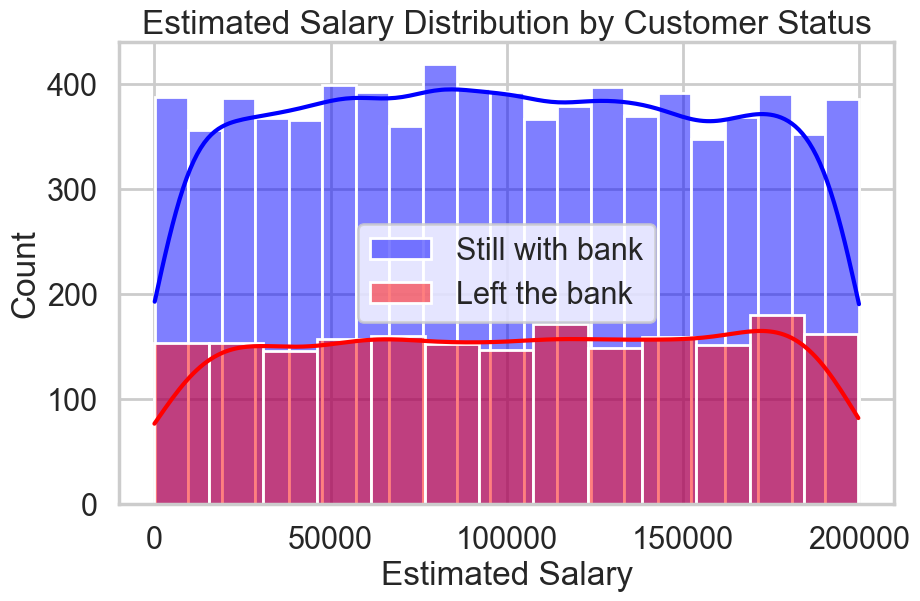

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df_0["EstimatedSalary"], color="blue", label="Still with bank", kde=True)
sns.histplot(df_1["EstimatedSalary"], color="red", label="Left the bank", kde=True)

plt.legend()
plt.title("Estimated Salary Distribution by Customer Status")
plt.xlabel("Estimated Salary")
plt.ylabel("Count")

plt.show()

In [ ]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

In [28]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0["EstimatedSalary"], df_1["EstimatedSalary"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.209653638019264
P-value: 0.22644042802223355


p-value ≥ 0.05 --> pas de différence significative

### Using Bootstrapping

In [ ]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

In [29]:
import numpy as np

# difference observée
mean_diff = df_1["EstimatedSalary"].mean() - df_0["EstimatedSalary"].mean()

# moyenne globale
overall_mean = df["EstimatedSalary"].mean()

# shift des groupes vers la moyenne globale
salary_stayed_shifted = df_0["EstimatedSalary"] - df_0["EstimatedSalary"].mean() + overall_mean
salary_left_shifted = df_1["EstimatedSalary"] - df_1["EstimatedSalary"].mean() + overall_mean

In [ ]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

In [30]:
bs_size = 10000

bs_stayed = bs_choice(salary_stayed_shifted, np.mean, bs_size)
bs_left = bs_choice(salary_left_shifted, np.mean, bs_size)

# difference bootstrap
bs_diff = bs_left - bs_stayed

In [ ]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

In [31]:
p_value_bootstrap = np.sum(bs_diff >= mean_diff) / len(bs_diff)

print("Observed difference in means:", mean_diff)
print("Bootstrap p-value:", p_value_bootstrap)

Observed difference in means: 1727.2857587371254
Bootstrap p-value: 0.1157


p-value ≥ 0.05 --> pas de différence significative --> ce qui confirme le tst precedent

### Conclusion
The t-test produced a p-value of 0.226 and the bootstrap test produced a p-value of 0.1157. 
Both p-values are greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis. This means there is no statistically 
significant difference in EstimatedSalary between customers who stayed with the bank 
and those who left.

EstimatedSalary does not appear to be a strong factor influencing customer churn.

## Final Conclusion
Les caractéristiques les plus utiles seront Age et CreditScore, éventuellement Balance (en particulier pour repérer les comptes à zéro). EstimatedSalary n’apporte pas de signal statistique fort et peut être ignorée ou pondérée faiblement dans un modèle prédictif.
